# Regression : Gecmis verilerden gelecegi tahmin etme

iki veya daha fazla degisken arasindaki iliskiyi analiz etmek kullanilan bir yontemdir. Bugun regression algoritmalarini derinlemesine ogrencegiz. Araba fiyatlarini tahmn eden bir makine ogrenme modeli gelistirecegiz. basari orani %85in uzerinde tutmaya calisacagiz.

In [1]:
#pip install xlrd==2.0.1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 


# EDA - Exploratory Data Analysis

In [3]:
df = pd.read_excel('cars.xls') 
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [4]:
df.sample()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
143,44205.875885,15104,Cadillac,STS-V8,Sedan 4D,Sedan,8,4.6,4,1,0,1


In [5]:
df.shape

(804, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Model     804 non-null    object 
 4   Trim      804 non-null    object 
 5   Type      804 non-null    object 
 6   Cylinder  804 non-null    int64  
 7   Liter     804 non-null    float64
 8   Doors     804 non-null    int64  
 9   Cruise    804 non-null    int64  
 10  Sound     804 non-null    int64  
 11  Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 75.5+ KB


In [7]:
df.describe() # istatistik bilgileri verir

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
count,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000
mean,21343.143767,19831.934080,5.268657,3.037313,3.527363,0.752488,0.679104,0.723881
std,9884.852801,8196.319707,1.387531,1.105562,0.850169,0.431836,0.467111,0.447355
min,8638.930895,266.000000,4.000000,1.600000,2.000000,0.000000,0.000000,0.000000
25%,14273.073870,14623.500000,4.000000,2.200000,4.000000,1.000000,0.000000,0.000000
50%,18024.995019,20913.500000,6.000000,2.800000,4.000000,1.000000,1.000000,1.000000
75%,26717.316636,25213.000000,6.000000,3.800000,4.000000,1.000000,1.000000,1.000000
max,70755.466717,50387.000000,8.000000,6.000000,4.000000,1.000000,1.000000,1.000000


In [8]:
df.corr(numeric_only=True) # korelasyon matrisi

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


<Axes: >

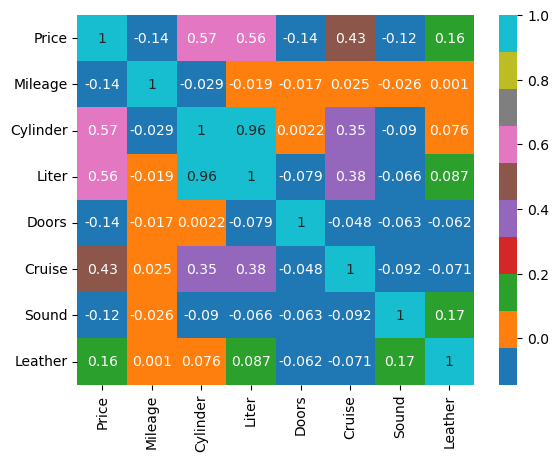

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='tab10') # korelasyon matrisi görselleştirme

In [10]:
df['Make'].unique() # araç markaları

array(['Buick', 'Cadillac', 'Chevrolet', 'Pontiac', 'SAAB', 'Saturn'],
      dtype=object)

In [11]:
df['Make'].value_counts() # araç markalarının sayısı

Make
Chevrolet    320
Pontiac      150
SAAB         114
Buick         80
Cadillac      80
Saturn        60
Name: count, dtype: int64

In [12]:
df['Make'].value_counts(normalize=True) # araç markalarının ortalaması

Make
Chevrolet    0.398010
Pontiac      0.186567
SAAB         0.141791
Buick        0.099502
Cadillac     0.099502
Saturn       0.074627
Name: proportion, dtype: float64

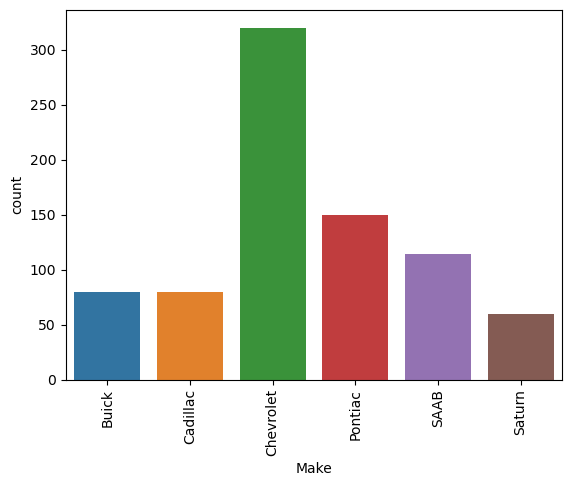

In [13]:
sns.countplot(x=df['Make'], hue=df['Make']); # araç markalarının görselleştirilmesi
plt.xticks(rotation=90); # x eksenindeki yazıları döndürme

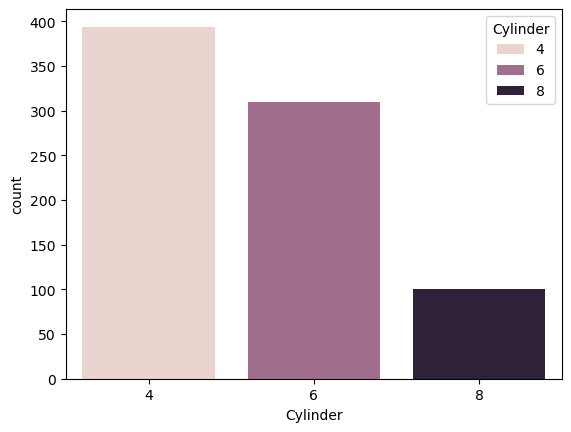

In [14]:
sns.countplot(x=df['Cylinder'], hue=df['Cylinder']); # Cylinder görselleştirilmesi

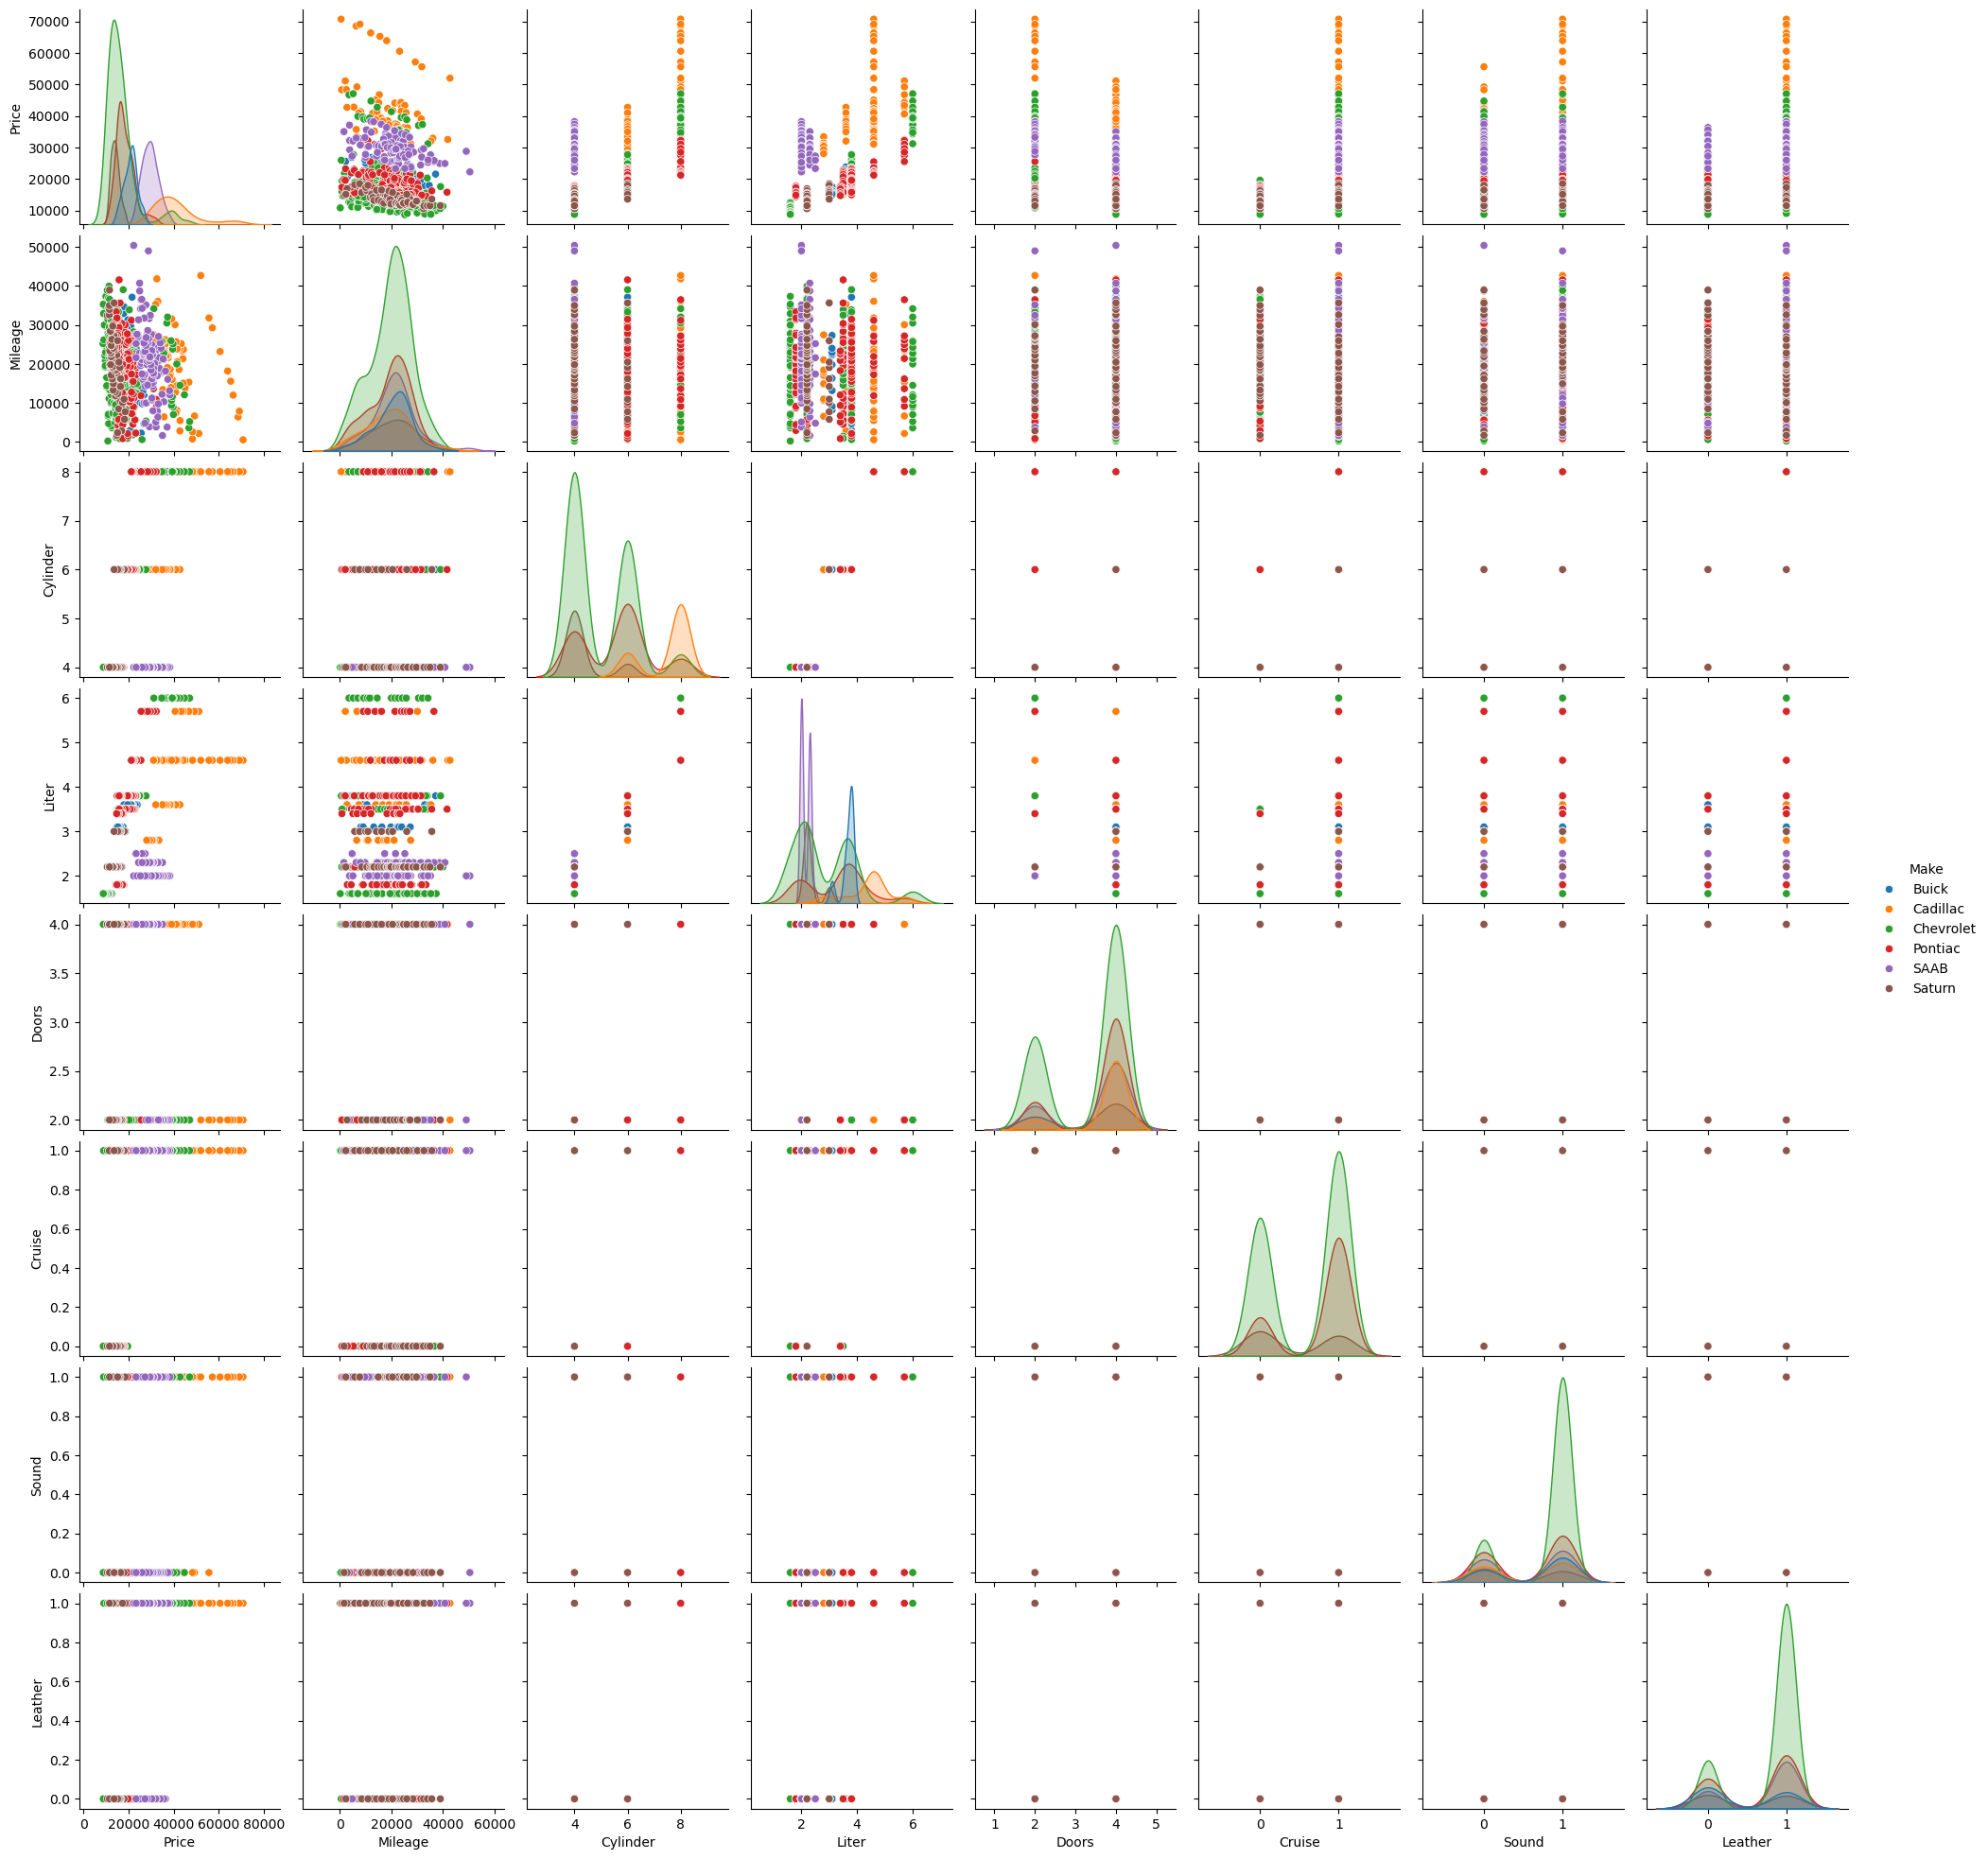

In [15]:
sns.pairplot(df, hue='Make'); # tüm değişkenlerin birbirleriyle ilişkisi

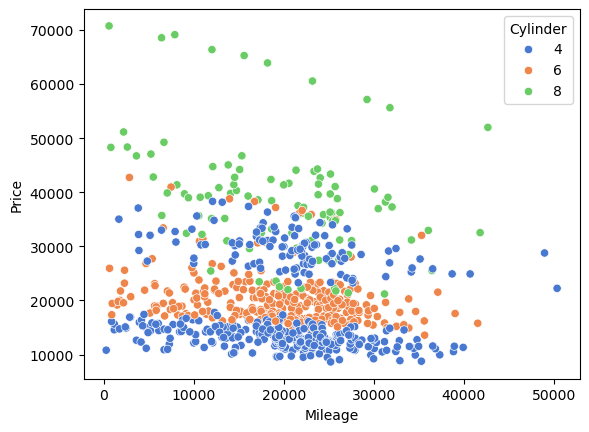

In [16]:
sns.scatterplot(x = df['Mileage'], y = df['Price'], hue = df['Cylinder'], palette='muted'); # Mileage ve Price ve Cylinder ilişkisi

## P- Value hesaplama

In [17]:
#sifir hipotezi
# H0: Mileage(KM) ve Price arasında ilişki yoktur.
# H1: Mileage(KM) ve Price arasında ilişki vardır.

# p değeri 0.05'ten küçükse H0 reddedilir, büyükse H0 kabul edilir.
# p degeri 0.05'ten buyukse sifir hipotezi kabul edilir.

In [18]:
from scipy.stats import ttest_ind

In [19]:
t,p = ttest_ind(df['Price'],df['Mileage'])

In [20]:
p

0.0008662338227446262

In [21]:
p < 0.05

True

In [22]:
# Sonuç: H0 reddedilir, H1 kabul edilir. Mileage(KM) ve Price arasında ilişki vardır. tesadufle aciklanamaz.

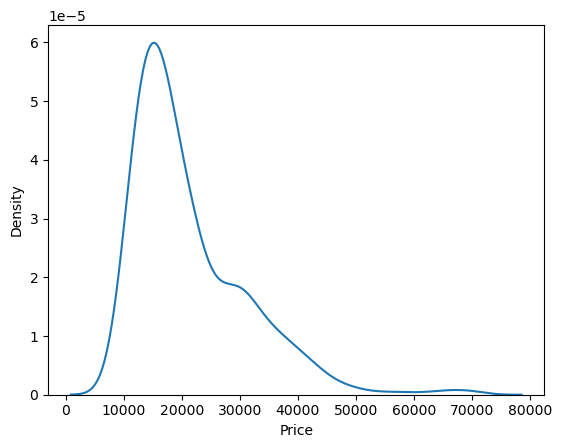

In [23]:
sns.kdeplot(df['Price'], ); # Price dağılımı

In [24]:
# boxplot outlierları gösterir

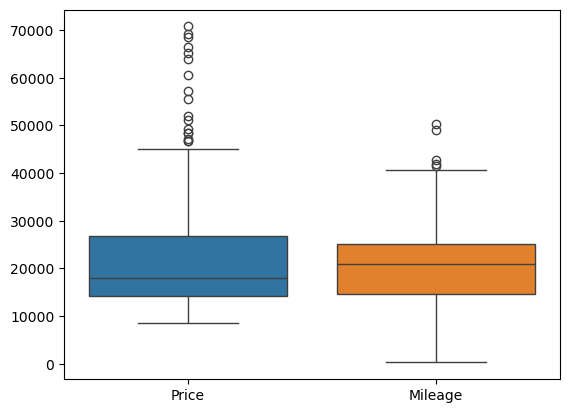

In [25]:
sns.boxplot([df['Price'], df['Mileage']]); # Price ve KM boxplot

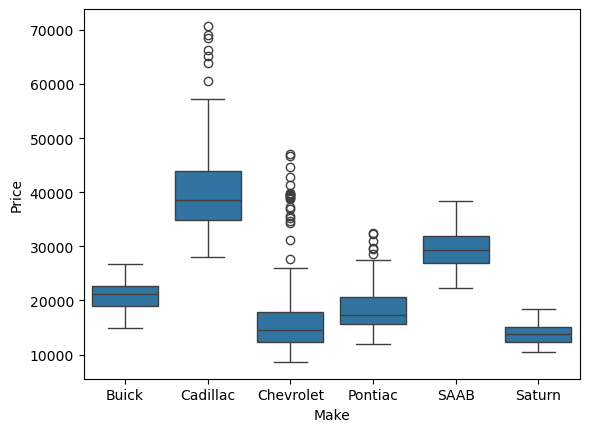

In [26]:
sns.boxplot(x=df['Make'], y=df['Price']); # Make ve Price boxplot

In [27]:
# Outlierin formulu : [ortalama +- 3* standart sapma] 

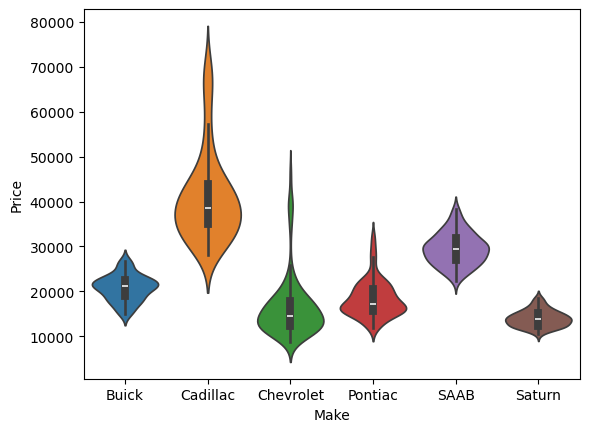

In [28]:
sns.violinplot(x=df['Make'], y=df['Price'], data=df, hue='Make'); # Make ve Price violinplot

In [29]:
import plotly.express as px

In [30]:
db = px.bar(df, x='Make', y='Price', color='Make'); # Make ve Price barplot
db.show()

In [31]:
ds = px.scatter_3d(df, x='Mileage', y='Price', z='Cylinder', color='Make'); # Mileage, Price ve Cylinder 3D scatter plot
ds.show()

In [32]:
ps = px.sunburst(df, path=['Make', 'Model', 'Trim'], values='Price'); 
ps.show()

### Feature Engineering

In [33]:
# Datanin aslinda olmayan fakat data kullanilarak yeni sutun olustumak.

In [34]:
df.corr(numeric_only=True)

,Price,Mileage,Cylinder,Liter,Doors,Cruise,Sound,Leather
Price,1.000000,-0.143051,0.569086,0.558146,-0.138750,0.430851,-0.124348,0.157197
Mileage,-0.143051,1.000000,-0.029461,-0.018641,-0.016944,0.025037,-0.026146,0.001005
Cylinder,0.569086,-0.029461,1.000000,0.957897,0.002206,0.354285,-0.089704,0.075520
Liter,0.558146,-0.018641,0.957897,1.000000,-0.079259,0.377509,-0.065527,0.087332
Doors,-0.138750,-0.016944,0.002206,-0.079259,1.000000,-0.047674,-0.062530,-0.061969
Cruise,0.430851,0.025037,0.354285,0.377509,-0.047674,1.000000,-0.091730,-0.070573
Sound,-0.124348,-0.026146,-0.089704,-0.065527,-0.062530,-0.091730,1.000000,0.165444
Leather,0.157197,0.001005,0.075520,0.087332,-0.061969,-0.070573,0.165444,1.000000


In [35]:
abs(df.corr(numeric_only=True)['Price'].sort_values(ascending=False)) # Price ile en cok korelasyon olan sutunlar

Price       1.000000
Cylinder    0.569086
Liter       0.558146
Cruise      0.430851
Leather     0.157197
Sound       0.124348
Doors       0.138750
Mileage     0.143051
Name: Price, dtype: float64

In [36]:
#golden rule: %20 ile %90 arasini al.

In [37]:
#Curse of dimensionality: cok fazla sutun olursa modelin performansi duser.

### Modeling

In [38]:
x = df[['Mileage', 'Cylinder', 'Liter','Cruise']] # Price ile en cok korelasyon olan sutunlar

In [39]:
y = df[['Price']]

In [40]:
from sklearn.model_selection import train_test_split # datayi train ve test olarak bolmek icin


In [41]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42) # test_size: test datasi oranı, random_state: random seed

In [42]:
x_train.shape

(643, 4)

In [43]:
y_train.shape

(643, 1)

In [44]:
x_test.shape

(161, 4)

In [45]:
y_test.shape

(161, 1)

In [46]:
from sklearn.linear_model import LinearRegression # linear regression modeli

In [47]:
lr = LinearRegression()

In [48]:
model = lr.fit(x_train, y_train) # modeli train etmek

In [49]:
tahmin = model.predict(x_test) # modeli test etmek

In [50]:
from sklearn.metrics import mean_squared_error, r2_score # modelin performansini olcmek icin

In [51]:
r2_score(y_test, tahmin) # r2 score

0.3071114906997997

In [52]:
x = df[['Mileage', 'Cylinder', 'Liter','Cruise','Make','Trim']]
x.head()

,Mileage,Cylinder,Liter,Cruise,Make,Trim
0,8221,6,3.1,1,Buick,Sedan 4D
1,9135,6,3.1,1,Buick,Sedan 4D
2,13196,6,3.1,1,Buick,Sedan 4D
3,16342,6,3.1,1,Buick,Sedan 4D
4,19832,6,3.1,1,Buick,Sedan 4D


In [53]:
x = pd.get_dummies(x, drop_first=True) # kategorik verileri sayısal verilere dönüştürmek için get_dummies kullanılır, drop_first=True ile ilk kategoriyi düşürerek multicollinearity sorununu önleriz.
x.head()

,Mileage,Cylinder,Liter,Cruise,Make_Cadillac,Make_Chevrolet,Make_Pontiac,Make_SAAB,Make_Saturn,Trim_Aero Conv 2D,...,Trim_Quad Coupe 2D,Trim_SE Sedan 4D,Trim_SLE Sedan 4D,Trim_SS Coupe 2D,Trim_SS Sedan 4D,Trim_SVM Hatchback 4D,Trim_SVM Sedan 4D,Trim_Sedan 4D,Trim_Special Ed Ultra 4D,Trim_Sportwagon 4D
0,8221,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,9135,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,13196,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,16342,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,19832,6,3.1,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [54]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [55]:
model = lr.fit(x_train, y_train) # modeli train etmek

In [56]:
tahmin = model.predict(x_test) # modeli test etmek

In [57]:
r2_score(y_test, tahmin) # r2 score

0.9707311770106378

In [58]:
mean_squared_error(y_test, tahmin)**.5 # root mean squared error

1523.6314728711307

In [59]:
karsilastirma = pd.DataFrame({'Gercek': y_test.values.flatten(), 'Tahmin': tahmin.flatten()}) # gerçek ve tahmin değerlerini karşılaştırmak için bir DataFrame oluşturuyoruz
karsilastirma

,Gercek,Tahmin
0,11302.902985,10743.235074
1,29114.544506,28087.016120
2,10777.052537,9632.819096
3,20677.593819,17768.160703
4,15253.868566,14759.782493
...,...,...
156,29142.714386,29954.784073
157,35575.417049,31550.020612
158,18042.221074,15681.059292
159,14881.955446,15843.761626


In [60]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet # Ridge regression modeli

In [61]:
R = Ridge() 
L = Lasso()
E = ElasticNet()

In [62]:
R.fit(x_train, y_train)

Ridge()

In [63]:
tahmin_2 = R.predict(x_test)

In [64]:
r2_score(y_test, tahmin_2)

0.9686973810318728

In [65]:
L.fit(x_train, y_train)

Lasso()

In [66]:
tahmin_3 = L.predict(x_test)

In [67]:
r2_score(y_test, tahmin_3)

0.9705999564419019

In [68]:
model.coef_ # modelin katsayıları

array([[-1.98809431e-01, -2.60219053e+03,  7.38331957e+03,
        -1.05024563e+02,  1.55364461e+04, -2.81688090e+03,
        -3.59594608e+03,  6.85100028e+03, -2.29878609e+03,
         3.90588224e+03, -2.64773527e+03, -1.26995361e+03,
         7.05993990e+03, -2.22310734e+02,  1.38127365e+02,
        -8.04390904e+03, -6.79607391e+03, -6.85437716e+03,
         3.54018314e+03, -5.72790226e+03, -1.11979437e+04,
        -8.32030557e+03, -7.59431897e+03, -8.10925499e+03,
        -6.53924263e+03, -3.82628105e+02, -5.76220228e+03,
        -3.63992297e+03,  1.67584142e+04, -5.32327214e+03,
        -7.83067529e+03, -4.64523486e+03, -7.53303979e+03,
        -6.65186020e+03, -7.63546793e+03, -6.87040602e+03,
        -6.33606759e+03, -3.92489639e+03, -7.03882417e+03,
        -6.17480932e+03, -8.14421976e+03,  4.52867027e+03,
        -2.53728086e+03, -2.10433902e+03, -7.88530569e+03,
        -6.07227049e+03, -6.65263910e+03, -5.53516395e+03,
        -4.78023915e+03, -3.13661125e+03, -6.92039280e+0

In [69]:
fi = pd.DataFrame({'Feature' : x_train.columns, 'Coefficient' : model.coef_.flatten()}) # modelin katsayılarını bir DataFrame'e dönüştürmek
fi.sort_values(by='Coefficient', ascending=False) # katsayıları büyükten küçüğe sıralamak

,Feature,Coefficient
28,Trim_Hardtop Conv 2D,16758.414214
4,Make_Cadillac,15536.446130
2,Liter,7383.319566
12,Trim_Arc Conv 2D,7059.939896
7,Make_SAAB,6851.000276
41,Trim_Linear Conv 2D,4528.670272
9,Trim_Aero Conv 2D,3905.882237
18,Trim_Conv 2D,3540.183141
14,Trim_Arc Wagon 4D,138.127365
0,Mileage,-0.198809


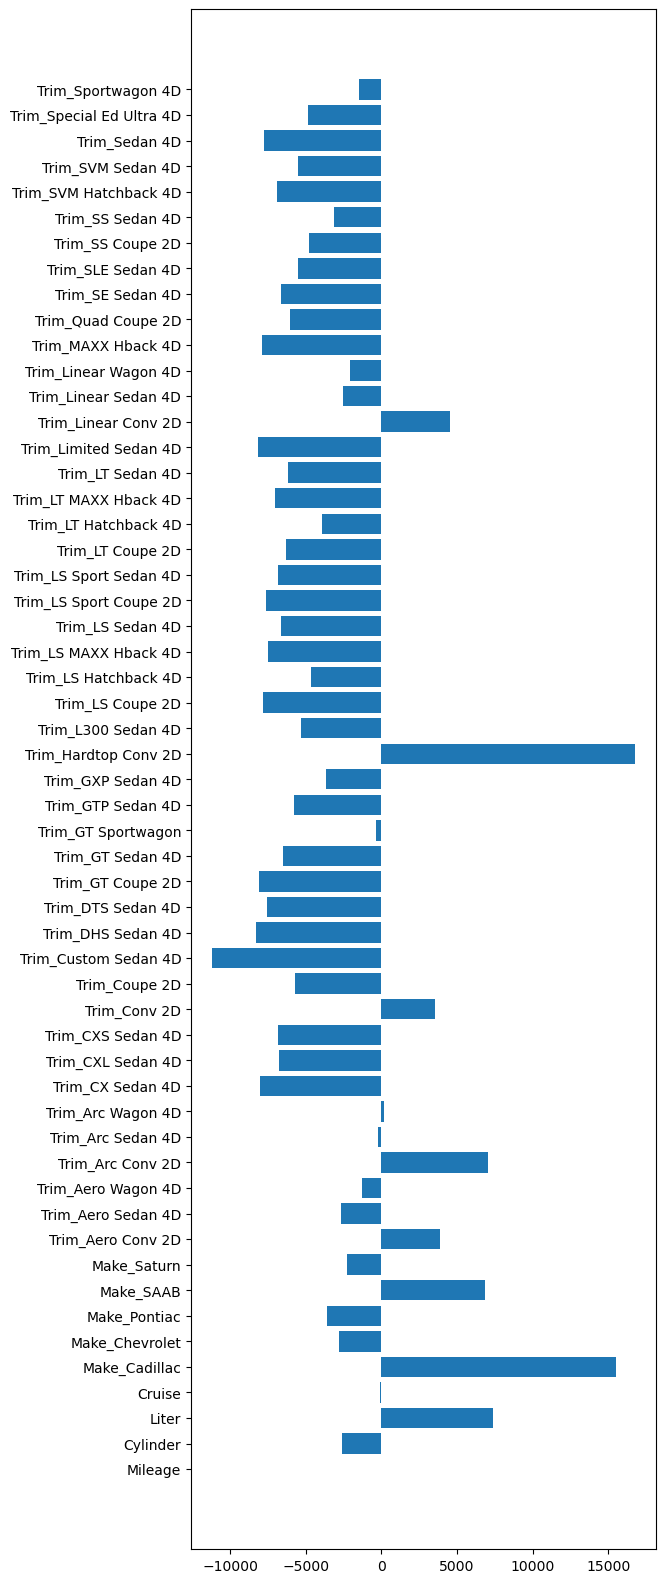

In [70]:
plt.figure(figsize=(6,20))
plt.barh(fi['Feature'], fi['Coefficient']); # modelin katsayılarını görselleştirmek

In [71]:
# Regression basarili olmasi icin gerekenler:
# 1. R2 score'un 0.85'den yuksek olmasi
# 2. RMSE'nin kucuk olmasi
# 3. residuals'in normal dagilmasi

In [72]:
resudials = y_test - tahmin # residuals hesaplama
resudials

,Price
192,559.667911
717,1027.528386
168,1144.233441
522,2909.433116
536,494.086073
...,...
658,-812.069687
356,4025.396437
525,2361.161783
748,-961.806180


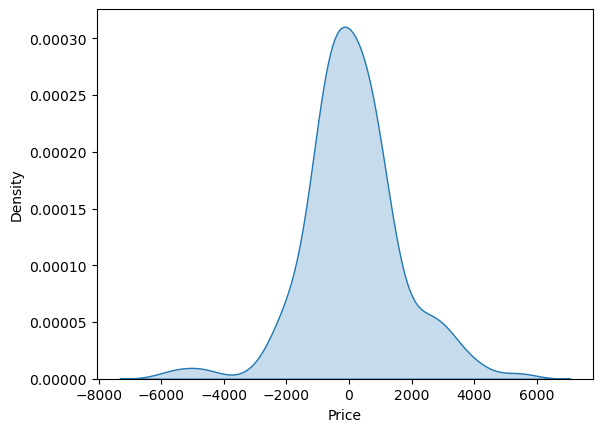

In [73]:
sns.kdeplot(x = resudials['Price'], fill=True); # residuals dağılımı

In [74]:
#pip install yellowbrick

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



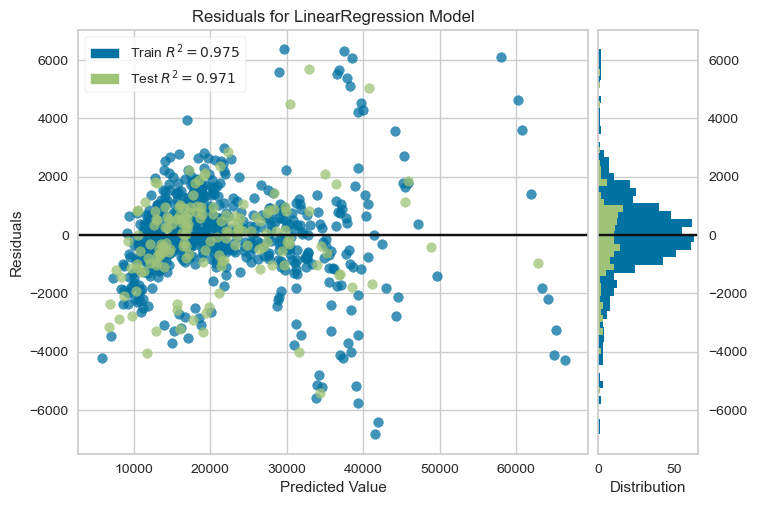

In [75]:
from yellowbrick.regressor import ResidualsPlot # residuals plot

vis = ResidualsPlot(lr) # modelin residuals plotunu oluşturmak
vis.fit(x_train, y_train) # modeli fit etmek
vis.score(x_test, y_test) # modeli score etmek
vis.show() # residuals plotunu göstermek
plt.show() # residuals plotunu göstermek


In [76]:
#normalizing data

In [77]:
from sklearn.preprocessing import MinMaxScaler # veriyi normalize etmek için MinMaxScaler kullanılır

In [78]:
x = MinMaxScaler().fit_transform(x) # veriyi normalize etmek

In [79]:
x

array([[0.15871591, 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       [0.17695178, 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       [0.2579757 , 0.5       , 0.34090909, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.40338381, 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ],
       [0.5130185 , 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ],
       [0.70621097, 0.5       , 0.31818182, ..., 0.        , 0.        ,
        0.        ]])

In [80]:
lr.fit(x_train, y_train) # modeli train etmek

LinearRegression()

In [81]:
tahmin = lr.predict(x_test) # modeli test etmek

In [82]:
r2_score(y_test, tahmin) # r2 score

0.9707311770106378

In [83]:
# Linear Olmayan Modeller

In [84]:
from sklearn.tree import DecisionTreeRegressor # Decision Tree Regressor modeli

In [85]:
dt = DecisionTreeRegressor()

In [86]:
dt.fit(x_train, y_train) # modeli train etmek

DecisionTreeRegressor()

In [87]:
tahmindt = dt.predict(x_test) # modeli test etmek

In [88]:
r2_score(y_test, tahmindt) # r2 score

0.9573644682608038

In [89]:
mean_squared_error(y_test, tahmindt)**.5 # root mean squared error

1838.9213197894376

In [90]:
from sklearn.ensemble import ExtraTreesRegressor # Random Forest Regressor modeli

In [91]:
ET = ExtraTreesRegressor()

In [92]:
ET.fit(x_train, y_train.values.ravel()) # modeli train etmek

ExtraTreesRegressor()

In [93]:
tahminet = ET.predict(x_test) # modeli test etmek

In [94]:
r2_score(y_test, tahminet) # r2 score

0.989330771038064

In [95]:
#pip install xgboost
#!pip uninstall xgboost -y
#!conda install -c conda-forge xgboost -y

^C

CondaError: KeyboardInterrupt



In [ ]:
# Burada araba fiyatlarini %99 dogruluk oraniyla tahmin eden bir model gelistirdik. En iyi model Extra Tree Regressor oldu.


In [97]:
!ARCHFLAGS="-arch x86_64" pip install xgboost --compile --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 668.7 kB/s eta 0:00:00a 0:00:01


In [98]:
from xgboost import XGBRegressor

In [99]:
xgb = XGBRegressor()

In [100]:
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [101]:
tahmin_xgb = xgb.predict(x_test)

In [102]:
r2_score(y_test, tahmin_xgb)

0.9858933687210083

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [107]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Extra Tree,0.986573,1031.951446,755.002636
XGBRegressor,0.985893,1057.763940,687.977806
Linear,0.970741,1523.368504,1091.170254
Lasso,0.970618,1526.562264,1119.320049
AdaBoost,0.969850,1546.393639,1158.430541
Gradient Boosting,0.968989,1568.332676,1155.790255
Ridge,0.964111,1687.172400,1272.172553
SGD,0.961829,1739.983866,1301.452371
Decision Tree,0.958372,1817.056612,1017.652832
KNeighborsRegressor,0.864098,3283.148279,2711.055803
